In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score,recall_score, f1_score, roc_auc_score


In [2]:
df = pd.read_excel(r"C:\Users\USER\Downloads\__דטאסט של מאמר 2 -עיבוד תכונות.xlsx")

df.head()


,Followers,Following,Following/Followers,Posts,Posts/(Following/Followers),Mutual Friends,Bio,Profile Picture,External Link,Threads,Labels,Labels.1,Threads.1,Profile Picture.1,External Link.1,Bio.1
0,2,2757,1378.500000,0,0.000000,0,0,0,0,0,2,Bot,N,N,N,N
1,2,505,252.500000,0,0.000000,0,0,1,0,0,3,Scam,N,Yes,N,N
2,6786,1782,0.262599,1589,6051.040404,10,1,0,1,0,0,Real,N,N,Yes,yes
3,21,1281,61.000000,0,0.000000,0,0,1,0,0,2,Bot,N,Yes,N,N
4,585,1682,2.875214,2663,926.192033,12,1,0,0,1,0,Real,Yes,N,N,yes


In [3]:
feature_order = ['Followers', 'Following', 'Following/Followers', 'Posts', 'Mutual Friends', 'Posts/(Following/Followers)', 'Bio', 'Profile Picture', 'External Link', 'Threads']
X = df[feature_order]
y = df['Labels']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

     Combination        F1  num_features
0        Initial  0.972654             0
1            F/F  0.973649             1
2        P/(F/F)  0.972985             1
3  F/F + P/(F/F)  0.970985             2


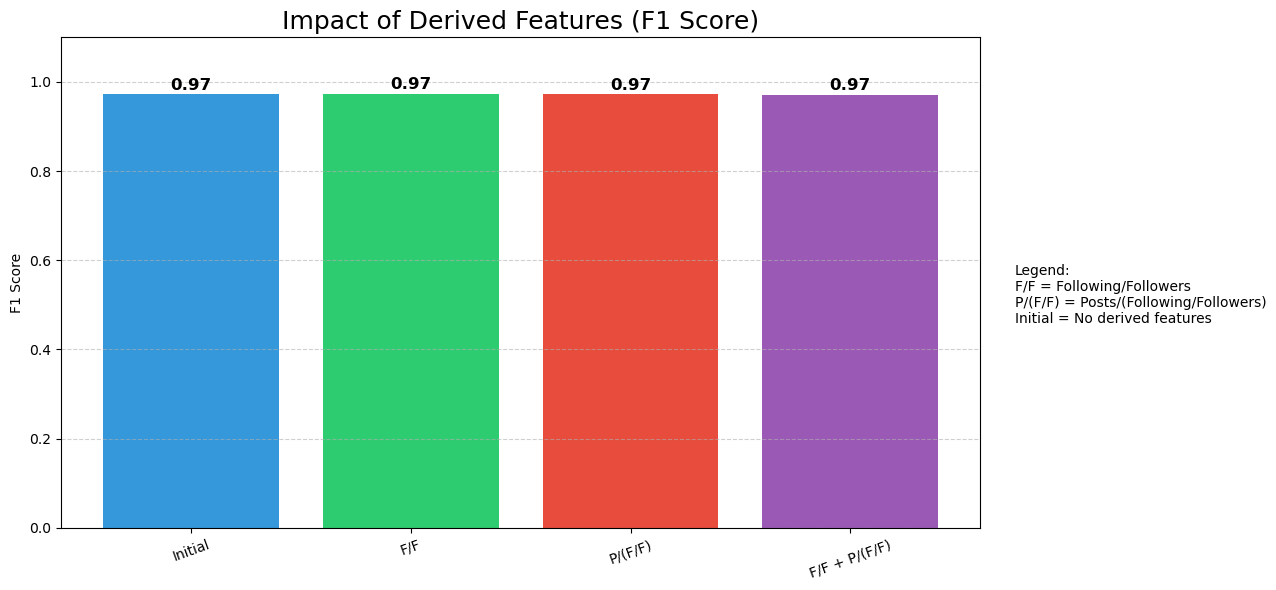

In [29]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'random_state': 42,
    'n_jobs': -1
}

derived_features = [
    'Following/Followers',
    'Posts/(Following/Followers)',
]

results = []

def short_name(combo):
    mapping = {
        'Following/Followers': 'F/F',
        'Posts/(Following/Followers)': 'P/(F/F)',
        'Posts' : 'F'
    }
    return " + ".join([mapping[c] for c in combo]) if combo else "Initial"

for r in range(len(derived_features)+1): 
    for combo in itertools.combinations(derived_features, r):

        drop_cols = [f for f in derived_features if f not in combo]
        features = X.drop(columns=drop_cols).columns.tolist()

        X_train_sub = X_train[features]
        X_test_sub = X_test[features]

        model = RandomForestClassifier(**rf_params)
        model.fit(X_train_sub, y_train)

        y_pred = model.predict(X_test_sub)

        f1 = f1_score(y_test, y_pred, average='weighted')

        results.append({
            "Combination": short_name(combo),
            "F1": f1,
            "num_features": r
        })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="num_features")

print(results_df)

plt.figure(figsize=(10,6))

bars = plt.bar(
    results_df['Combination'],
    results_df['F1'],
    color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
)

plt.title("Impact of Derived Features (F1 Score)", fontsize=18)
plt.ylabel("F1 Score")
plt.ylim(0, 1.1)

plt.xticks(rotation=20)

# ערכים מעל העמודות
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f"{yval:.2f}",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

# מקרא
legend_text = (
    "Legend:\n"
    "F/F = Following/Followers\n"
    "P/(F/F) = Posts/(Following/Followers)\n"
    "Initial = No derived features"
)

plt.gcf().text(1.02, 0.5, legend_text, fontsize=10, va='center')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

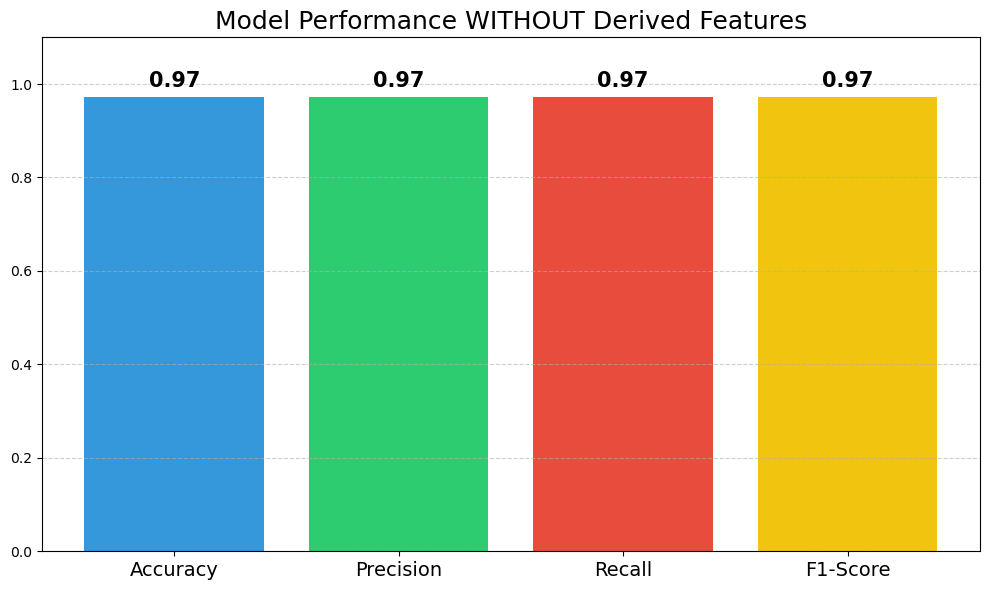

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt

rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'random_state': 42,
    'n_jobs': -1
}

derived_features = [
    'Following/Followers',
    'Posts/(Following/Followers)', 
]

features = [f for f in X.columns if f not in derived_features]

# דאטה ללא הפיצ'רים הנגזרים
X_train_sub = X_train[features]
X_test_sub = X_test[features]

# אימון מודל
model = RandomForestClassifier(**rf_params)
model.fit(X_train_sub, y_train)

# חיזוי
y_pred = model.predict(X_test_sub)

# מדדים
results = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, average='weighted'),
    "recall": recall_score(y_test, y_pred, average='weighted'),
    "f1": f1_score(y_test, y_pred, average='weighted')
}

values = list(results.values())

# גרף
plt.figure(figsize=(10,6))

bars = plt.bar(
    ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    values,
    color=['#3498db', '#2ecc71', '#e74c3c', '#f1c40f']
)

plt.title("Model Performance WITHOUT Derived Features", fontsize=18)
plt.ylim(0, 1.1)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center',
        fontsize=15,
        fontweight='bold'
    )

plt.xticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

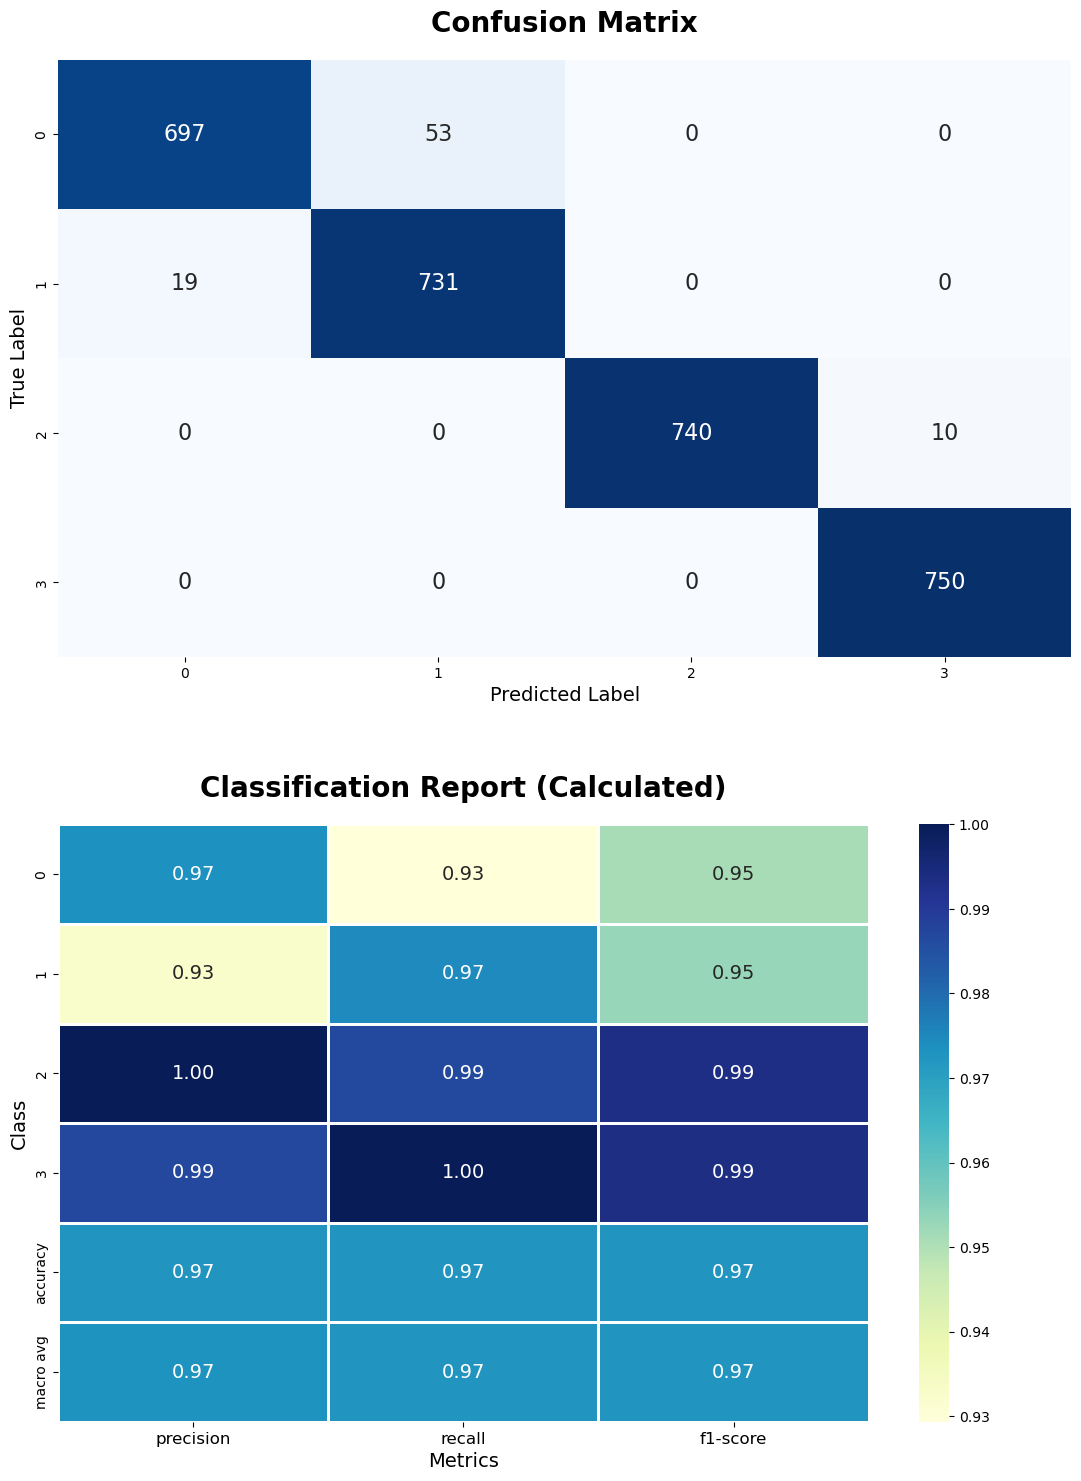

In [31]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ייצור דוח סיווג ובעבור כל מחלקה מייצר מדדי דיוק
report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred) #בניית המטריצה בפועל 

report_df = pd.DataFrame(report).transpose()
#0 1 2 3 
class_names = [c for c in report_df.index if c not in ['accuracy', 'macro avg', 'weighted avg']]

# הכנסת ערך אחיד במדד הדיוק לשלושת העמודות 
acc_val = report['accuracy']
acc_row = pd.DataFrame([[acc_val, acc_val, acc_val]], 
                       columns=['precision', 'recall', 'f1-score'], 
                       index=['accuracy'])

final_report_df = pd.concat([
    report_df.loc[class_names, ['precision', 'recall', 'f1-score']],
    acc_row,
    report_df.loc[['macro avg'], ['precision', 'recall', 'f1-score']]
])

# 3. יצירת הויזואליזציה - אחד מתחת לשני
fig, ax = plt.subplots(2, 1, figsize=(12, 16)) # 2 שורות, עמודה 1

# גרף עליון מטריצת בילבול
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False, annot_kws={"size": 16})
ax[0].set_title('Confusion Matrix', fontsize=20, fontweight='bold', pad=20)
ax[0].set_xlabel('Predicted Label', fontsize=14)
ax[0].set_ylabel('True Label', fontsize=14)

# Classification Report גרף תחתון 
sns.heatmap(final_report_df, annot=True, cmap='YlGnBu', ax=ax[1], fmt='.2f', 
            annot_kws={"size": 14}, linewidths=1, linecolor='white')

ax[1].set_title('Classification Report (Calculated)', fontsize=20, fontweight='bold', pad=20)
ax[1].set_xlabel('Metrics', fontsize=14)
ax[1].set_ylabel('Class', fontsize=14)
ax[1].set_xticklabels(['precision', 'recall', 'f1-score'], fontsize=12)

# מרווח בין הגרפים כדי שלא יחפפו
plt.tight_layout(pad=5.0)
plt.show()

In [43]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'random_state': 42,
    'n_jobs': -1
}

derived_features = [
    'Following/Followers',
    'Posts/(Following/Followers)'
]

feature_columns = [
    f for f in X.columns
    if f not in derived_features
]

X_train_sub = X_train[feature_columns]
X_test_sub = X_test[feature_columns]

model = RandomForestClassifier(**rf_params)
model.fit(X_train_sub, y_train)

def get_yes_no(prompt):
    while True:
        choice = input(prompt + " (yes/no): ").lower().strip()
        if choice == "yes":
            return 1
        elif choice == "no":
            return 0
        else:
            print("Please type yes or no only.")

def predict_instagram_interactive_full(model, feature_columns):

    print("===================================")
    print(" Instagram Fake Account Detector ")
    print("===================================\n")

    data = {}

    # מספריים
    for field in ['Followers', 'Following', 'Posts', 'Mutual Friends']:
        while True:
            try:
                data[field] = float(input(f"Enter {field}: "))
                break
            except:
                print("Please enter numbers only.")

    # yes/no
    for field in ['Bio', 'Profile Picture', 'External Link', 'Threads']:
        data[field] = get_yes_no(f"Does the account have {field}?")

    # DataFrame
    input_df = pd.DataFrame([data])

    # חשוב: התאמה למודל
    input_df = input_df[feature_columns]

    # Prediction
    prediction = model.predict(input_df)[0]
    probabilities = model.predict_proba(input_df)[0]
    confidence = np.max(probabilities) * 100

    labels_map = {
        0: "Real",
        1: "Spam",
        2: "Bot",
        3: "Scam"
    }

    result = labels_map[prediction]

    print("\n===================================")
    print(f"Prediction : {result}")
    print(f"Confidence : {confidence:.2f}%")
    print("===================================")

    return result, confidence

prediction, confidence = predict_instagram_interactive_full(
    model,
    feature_columns
)

 Instagram Fake Account Detector 



Enter Followers:  5
Enter Following:  766
Enter Posts:  0
Enter Mutual Friends:  0
Does the account have Bio? (yes/no):  yes
Does the account have Profile Picture? (yes/no):  yes
Does the account have External Link? (yes/no):  yes
Does the account have Threads? (yes/no):  no



Prediction : Scam
Confidence : 75.85%
